<a href="https://colab.research.google.com/github/VukasinA/ML_projekti/blob/main/DubokoUcenje1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

fatal: destination path 'RAF-PetFinder-dataset' already exists and is not an empty directory.
DEVICE = cpu
Looking for data in RAF-PetFinder-dataset/Data
train shape (14993, 24)
sentiment shape (14442, 3)


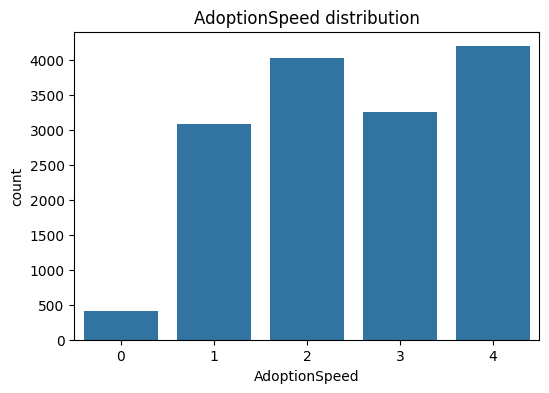

AdoptionSpeed
0    0.027346
1    0.206096
2    0.269259
3    0.217368
4    0.279931
Name: proportion, dtype: float64


<Figure size 800x400 with 0 Axes>

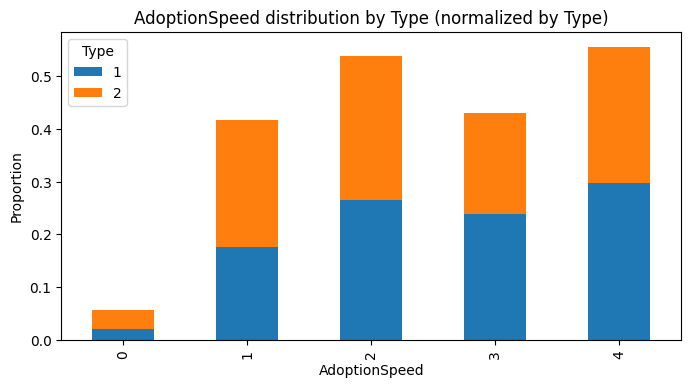

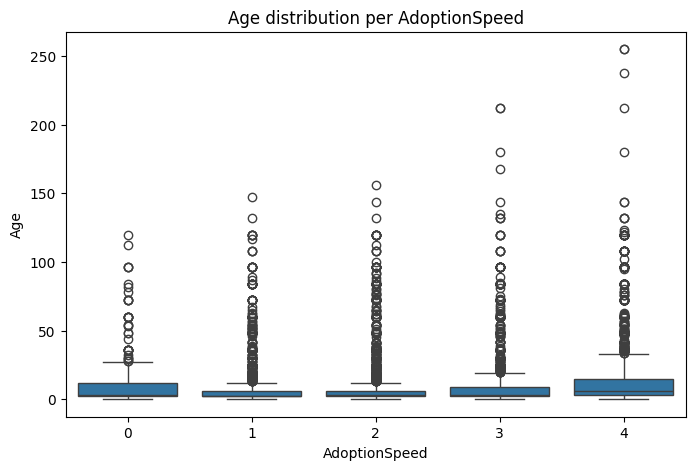

AttributeError: 'SeriesGroupBy' object has no attribute 'kurtosis'

In [ ]:
"""
Jupyter/Colab-ready notebook for PetFinder AdoptionSpeed project
Contents:
- Setup (clone repo or upload data)
- Install dependencies
- Imports & seeds
- Load data + merge sentiment
- EDA (>=6 analyses: >=2 image, >=4 tabular) + statistical moments
- Preprocessing (tabular + images)
- Dataset class and DataLoaders
- Models: A (LightGBM), B (Image-only ResNet18), C (Multimodal ResNet18+Tabular)
- Training loops, evaluation (accuracy, cohen_kappa_score), plotting
- Save models & artifacts

How to use in Colab:
1) Open https://colab.research.google.com/
2) New Python 3 notebook
3) In first cell: upload this notebook content or run this file as script via `%run /content/path/to/this_file.py` or copy/paste cells.
4) Alternatively, clone the GitHub repo that contains `data/`:
   !git clone https://github.com/MilanBojic1999/RAF-PetFinder-dataset.git
   and set DATA_DIR = 'RAF-PetFinder-dataset/data'
5) Run cells sequentially. See comments in cells for tips.

NOTE: This is a single-file python script formatted as Jupyter cells. When pasting into Colab, split by the `# %%` cell separators.
"""

# %%
# Cell 0 - Setup: mount drive or clone repo (uncomment as needed)
# If you have the dataset on GitHub, clone it. Otherwise upload the 'data' folder to Colab.
# Uncomment one of the following options.

# Option A: Clone the repo (internet required)
!git clone https://github.com/MilanBojic1999/RAF-PetFinder-dataset.git
DATA_DIR = 'RAF-PetFinder-dataset/Data'

# Option B: If you uploaded the `data` folder manually to Colab's /content/data
#DATA_DIR = '/content/data'

# If using Google Drive to store data, mount drive
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = '/content/drive/MyDrive/path_to_data'

# %%
# Cell 1 - Install dependencies (uncomment to run)
# !pip install -q lightgbm==3.3.2 scikit-learn==1.2.2 torch torchvision matplotlib seaborn joblib opencv-python

# %%
# Cell 2 - Imports and seeds
import os
import random
import math
import json
import glob
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, cohen_kappa_score

import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE =', DEVICE)

# %%
# Cell 3 - Load CSVs
print('Looking for data in', DATA_DIR)
train_csv = os.path.join(DATA_DIR, 'train.csv')
train_sentiment_csv = os.path.join(DATA_DIR, 'train_sentiment.csv')
breed_labels = os.path.join(DATA_DIR, 'breed_labels.csv')
color_labels = os.path.join(DATA_DIR, 'color_labels.csv')
state_labels = os.path.join(DATA_DIR, 'state_labels.csv')
images_dir = os.path.join(DATA_DIR, 'train_images')

assert os.path.exists(train_csv), f"train.csv not found in {DATA_DIR}"
train = pd.read_csv(train_csv)
print('train shape', train.shape)

if os.path.exists(train_sentiment_csv):
    sent = pd.read_csv(train_sentiment_csv)
    print('sentiment shape', sent.shape)
    train = train.merge(sent, on='PetID', how='left')
else:
    train['SentimentScore'] = 0.0
    train['SentimentMagnitude'] = 0.0

# load label maps (optional)
if os.path.exists(breed_labels):
    breed_df = pd.read_csv(breed_labels)
if os.path.exists(color_labels):
    color_df = pd.read_csv(color_labels)
if os.path.exists(state_labels):
    state_df = pd.read_csv(state_labels)

# quick glance
train.head()

# %%
# Cell 4 - Basic EDA: target distribution and counts
plt.figure(figsize=(6,4))
sns.countplot(x='AdoptionSpeed', data=train, order=sorted(train['AdoptionSpeed'].unique()))
plt.title('AdoptionSpeed distribution')
plt.show()

print(train['AdoptionSpeed'].value_counts(normalize=True).sort_index())

# %%
# Cell 5 - EDA: Type (dog/cat) vs AdoptionSpeed
plt.figure(figsize=(8,4))
ct = pd.crosstab(train['Type'], train['AdoptionSpeed'], normalize='index')
ct.T.plot(kind='bar', stacked=True, figsize=(8,4))
plt.title('AdoptionSpeed distribution by Type (normalized by Type)')
plt.xlabel('AdoptionSpeed')
plt.ylabel('Proportion')
plt.show()

# %%
# Cell 6 - EDA: Age vs AdoptionSpeed (boxplot) + stats
plt.figure(figsize=(8,5))
sns.boxplot(x='AdoptionSpeed', y='Age', data=train)
plt.title('Age distribution per AdoptionSpeed')
plt.show()

# compute mean and std per class
stats_age = train.groupby('AdoptionSpeed')['Age'].agg(['count','mean','std','skew','kurtosis']).reset_index()
print(stats_age)

# %%
# Cell 7 - Numeric correlation heatmap + include Sentiment
num_cols = ['Age','Quantity','Fee','PhotoAmt','VideoAmt','SentimentScore','SentimentMagnitude']
plt.figure(figsize=(8,6))
cm = train[num_cols].corr()
sns.heatmap(cm, annot=True, fmt='.2f')
plt.title('Correlation matrix (numerical)')
plt.show()

# %%
# Cell 8 - Image-based analysis 1: number of photos per PetID
# The CSV may not contain all images; count files in train_images folder
all_files = glob.glob(os.path.join(images_dir, '*.jpg')) if os.path.exists(images_dir) else []
print('Total image files found:', len(all_files))

# map PetID -> count
img_counts = Counter()
for f in all_files:
    fname = os.path.basename(f)
    petid = fname.split('-')[0]
    img_counts[petid] += 1

img_count_df = pd.DataFrame.from_records(list(img_counts.items()), columns=['PetID','PhotoCount'])
# merge counts
train = train.merge(img_count_df, on='PetID', how='left')
train['PhotoCount'] = train['PhotoCount'].fillna(0).astype(int)

plt.figure(figsize=(6,4))
plt.hist(train['PhotoCount'].clip(0,10), bins=11)
plt.title('Histogram of PhotoCount (clipped at 10)')
plt.xlabel('PhotoCount')
plt.show()

# relationship PhotoCount vs AdoptionSpeed
plt.figure(figsize=(8,4))
sns.boxplot(x='AdoptionSpeed', y='PhotoCount', data=train)
plt.title('PhotoCount by AdoptionSpeed')
plt.show()

# %%
# Cell 9 - Image-based analysis 2: sample images per class and mean brightness
from torchvision import transforms

def get_image_path_for(petid):
    p1 = os.path.join(images_dir, f"{petid}-1.jpg")
    if os.path.exists(p1):
        return p1
    # fallback: first matching
    for f in glob.glob(os.path.join(images_dir, f"{petid}-*.jpg")):
        return f
    return None

sample_grid = {}
mean_brightness = []
for cls in sorted(train['AdoptionSpeed'].unique()):
    subset = train[train['AdoptionSpeed']==cls].sample(min(5, len(train[train['AdoptionSpeed']==cls])), random_state=SEED)
    imgs = []
    for pid in subset['PetID']:
        p = get_image_path_for(pid)
        if p:
            im = Image.open(p).convert('RGB')
            imgs.append(np.array(im.resize((128,128))).mean())
    mean_brightness.append({'cls':cls,'mean_brightness':np.mean(imgs) if imgs else np.nan})

print(pd.DataFrame(mean_brightness))

# show example images grid
fig, axes = plt.subplots(5,5, figsize=(10,10))
axes = axes.flatten()
idx = 0
for cls in sorted(train['AdoptionSpeed'].unique()):
    subset = train[train['AdoptionSpeed']==cls].sample(min(5, len(train[train['AdoptionSpeed']==cls])), random_state=SEED)
    for pid in subset['PetID']:
        p = get_image_path_for(pid)
        if p:
            im = Image.open(p).convert('RGB').resize((128,128))
            axes[idx].imshow(im)
        else:
            axes[idx].text(0.5,0.5,'no image',ha='center')
        axes[idx].axis('off')
        idx += 1
        if idx>=25: break
    if idx>=25: break
plt.suptitle('Sample images (up to 25)')
plt.show()

# %%
# Cell 10 - Additional statistical moments: skewness/kurtosis for PhotoAmt and Age
from scipy.stats import skew, kurtosis
print('PhotoAmt skew/kurt:', skew(train['PhotoAmt'].fillna(0)), kurtosis(train['PhotoAmt'].fillna(0)))
print('Age skew/kurt:', skew(train['Age'].fillna(0)), kurtosis(train['Age'].fillna(0)))

# %%
# Cell 11 - Feature engineering (tabular preprocessing)
# We'll create a set of numerical features ready for model training

def prepare_tabular(df, fit_scaler=None):
    out = df.copy()
    # fill NA
    out['Breed2'] = out['Breed2'].fillna(0)
    out['Color2'] = out['Color2'].fillna(0)
    out['Color3'] = out['Color3'].fillna(0)
    out['Name'] = out['Name'].fillna('')
    # frequency encode RescuerID
    resc_counts = out['RescuerID'].value_counts().to_dict()
    out['Rescuer_freq'] = out['RescuerID'].map(resc_counts).fillna(0)
    # numeric cols
    num_cols = ['Age','Quantity','Fee','PhotoAmt','VideoAmt','SentimentScore','SentimentMagnitude','Rescuer_freq','PhotoCount']
    out[num_cols] = out[num_cols].fillna(0)
    # label encode small categorical columns
    # we'll label encode Type, Gender, MaturitySize, FurLength, Vaccinated, Dewormed, Sterilized, Health, State
    cat_cols = ['Type','Gender','MaturitySize','FurLength','Vaccinated','Dewormed','Sterilized','Health','State']
    for c in cat_cols:
        out[c] = out[c].fillna(0).astype(str)
        out[c+'_le'] = LabelEncoder().fit_transform(out[c])
    # final feature list
    feat_cols = num_cols + [c+'_le' for c in cat_cols]
    if fit_scaler is None:
        scaler = StandardScaler()
        out[feat_cols] = scaler.fit_transform(out[feat_cols])
        return out, feat_cols, scaler
    else:
        out[feat_cols] = fit_scaler.transform(out[feat_cols])
        return out, feat_cols

train_pre, feat_cols, scaler = prepare_tabular(train)
print('features used:', feat_cols)

# save scaler
joblib.dump(scaler, 'scaler.joblib')

# %%
# Cell 12 - Train/val/test split
train_df, temp_df = train_test_split(train_pre, test_size=0.30, random_state=SEED, stratify=train_pre['AdoptionSpeed'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['AdoptionSpeed'])
print('train/val/test sizes:', len(train_df), len(val_df), len(test_df))

# %%
# Cell 13 - PyTorch Dataset + DataLoader
class PetDataset(Dataset):
    def __init__(self, df, feat_cols, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.feat_cols = feat_cols
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _get_image_path(self, petid):
        p1 = os.path.join(self.image_dir, f"{petid}-1.jpg")
        if os.path.exists(p1):
            return p1
        # fallback to any
        lst = glob.glob(os.path.join(self.image_dir, f"{petid}-*.jpg"))
        return lst[0] if lst else None

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        petid = row['PetID']
        img_path = self._get_image_path(petid)
        if img_path and os.path.exists(img_path):
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
        else:
            # return zeros image
            img = torch.zeros(3,224,224)
        tab = torch.tensor(row[self.feat_cols].values.astype(np.float32))
        label = int(row['AdoptionSpeed'])
        return img, tab, label

# transforms
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_ds = PetDataset(train_df, feat_cols, images_dir, transform=train_transforms)
val_ds = PetDataset(val_df, feat_cols, images_dir, transform=val_transforms)
test_ds = PetDataset(test_df, feat_cols, images_dir, transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

# %%
# Cell 14 - Model B: Image-only ResNet18
class ImageOnlyModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = models.resnet18(pretrained=True)
        in_f = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.head = nn.Sequential(
            nn.Linear(in_f, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        feats = self.backbone(x)
        out = self.head(feats)
        return out

# Model C: Multimodal
class MultimodalModel(nn.Module):
    def __init__(self, tab_input_dim, num_classes=5):
        super().__init__()
        self.backbone = models.resnet18(pretrained=True)
        in_f = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.tab_mlp = nn.Sequential(
            nn.Linear(tab_input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2)
        )
        self.fusion = nn.Sequential(
            nn.Linear(in_f + 128, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
    def forward(self, image, tab):
        img_feat = self.backbone(image)
        tab_feat = self.tab_mlp(tab)
        x = torch.cat([img_feat, tab_feat], dim=1)
        return self.fusion(x)

# %%
# Cell 15 - Training and evaluation utilities
from tqdm.auto import tqdm

def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    running_loss = 0.0
    y_true = []
    y_pred = []
    for images, tabs, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        tabs = tabs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        if isinstance(model, MultimodalModel):
            outputs = model(images, tabs)
        else:
            outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(labels.detach().cpu().numpy().tolist())
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc


def eval_model(model, loader, loss_fn):
    model.eval()
    running_loss = 0.0
    y_true = []
    y_pred = []
    with torch.no_grad():
        for images, tabs, labels in tqdm(loader, leave=False):
            images = images.to(DEVICE)
            tabs = tabs.to(DEVICE)
            labels = labels.to(DEVICE)
            if isinstance(model, MultimodalModel):
                outputs = model(images, tabs)
            else:
                outputs = model(images)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1).detach().cpu().numpy()
            y_pred.extend(preds.tolist())
            y_true.extend(labels.detach().cpu().numpy().tolist())
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    try:
        kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    except Exception:
        kappa = np.nan
    return avg_loss, acc, kappa, y_true, y_pred

# %%
# Cell 16 - Quick experiment runner (train small epochs to verify)

def run_experiment(model, name, train_loader, val_loader, epochs=3, lr=1e-4):
    model = model.to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_kappa':[]}
    for ep in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, loss_fn)
        val_loss, val_acc, val_kappa, _, _ = eval_model(model, val_loader, loss_fn)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_kappa'].append(val_kappa)
        print(f"{name} Ep{ep+1}/{epochs} train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_kappa={val_kappa:.4f}")
    # save model
    torch.save(model.state_dict(), f'{name}_model.pth')
    return model, history

# %%
# Cell 17 - Run Model B (Image-only) - small sanity run
img_model = ImageOnlyModel(num_classes=5)
img_model, hist_img = run_experiment(img_model, 'image_only', train_loader, val_loader, epochs=2, lr=1e-4)

# %%
# Cell 18 - Run Model C (Multimodal) - small sanity run
mm_model = MultimodalModel(tab_input_dim=len(feat_cols), num_classes=5)
mm_model, hist_mm = run_experiment(mm_model, 'multimodal', train_loader, val_loader, epochs=2, lr=1e-4)

# %%
# Cell 19 - Evaluate on test set
loss_fn = nn.CrossEntropyLoss()
_, img_test_acc, img_test_kappa, y_true_img, y_pred_img = eval_model(img_model, test_loader, loss_fn)
print('Image-only test acc, kappa:', img_test_acc, img_test_kappa)

_, mm_test_acc, mm_test_kappa, y_true_mm, y_pred_mm = eval_model(mm_model, test_loader, loss_fn)
print('Multimodal test acc, kappa:', mm_test_acc, mm_test_kappa)

# %%
# Cell 20 - LightGBM tabular-only baseline
try:
    import lightgbm as lgb
    TAB_X = train_df[feat_cols]
    TAB_y = train_df['AdoptionSpeed']
    TAB_val_X = val_df[feat_cols]
    TAB_val_y = val_df['AdoptionSpeed']
    dtrain = lgb.Dataset(TAB_X, label=TAB_y)
    dval = lgb.Dataset(TAB_val_X, label=TAB_val_y)
    params = {
        'objective':'multiclass',
        'num_class':5,
        'metric':'multi_logloss',
        'learning_rate':0.05,
        'num_leaves':31,
        'seed':SEED
    }
    gbm = lgb.train(params, dtrain, valid_sets=[dtrain,dval], num_boost_round=200, early_stopping_rounds=20, verbose_eval=20)
    val_pred = gbm.predict(TAB_val_X)
    val_pred_labels = np.argmax(val_pred, axis=1)
    print('LightGBM val acc:', accuracy_score(TAB_val_y, val_pred_labels), 'kappa:', cohen_kappa_score(TAB_val_y, val_pred_labels, weights='quadratic'))
    joblib.dump(gbm, 'lightgbm_tabular.pkl')
except Exception as e:
    print('LightGBM training failed:', e)

# %%
# Cell 21 - Plot training curves helper
def plot_history(hist, title='Training curves'):
    plt.figure(figsize=(8,4))
    plt.plot(hist['train_loss'], label='train_loss')
    plt.plot(hist['val_loss'], label='val_loss')
    plt.legend()
    plt.title(title)
    plt.show()

plot_history(hist_img, 'Image-only')
plot_history(hist_mm, 'Multimodal')

# %%
# Cell 22 - Save key artifacts and create a minimal report
os.makedirs('artifacts', exist_ok=True)
joblib.dump(feat_cols, 'artifacts/feat_cols.joblib')
joblib.dump(scaler, 'artifacts/scaler.joblib')

print('Saved artifacts in ./artifacts and models in ./')

# End of notebook
